In [1]:
import os
import numpy as np
import pandas as pd
import random
import torch
from torch import nn
from torch.nn import TransformerEncoder, TransformerEncoderLayer, TransformerDecoderLayer, TransformerDecoder
import matplotlib.pyplot as plt
from scipy.signal import cont2discrete, lti, dlti, dstep
from sklearn.model_selection import train_test_split
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, random_split
import math
import scipy.integrate
import random
import autograd.numpy as np
from autograd import grad, jacobian
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


C:\Users\joshr\AppData\Local\Temp\ipykernel_23364\2110139111.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Using device: cuda


In [2]:
def set_seed(seed):
    """Sets the seed for reproducibility."""
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) 
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)  # Positional encoding tensor
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) # (max_len, 1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)  # Apply sine to even indices
        pe[:, 1::2] = torch.cos(position * div_term)  # Apply cosine to odd indices
        pe = pe.unsqueeze(0)  # # Add a batch dimension to the positional encoding (1, seq_len, d_model)
        self.register_buffer('pe', pe)  # Register the positional encoding as a buffer(non-trainable)

    def forward(self, x):
        # Add positional encoding to the input tensor
        x = x + self.pe[:, :x.size(1)]
        return x


class KalmanFormer(nn.Module):
    def __init__(self, f, h, m, n, hidden_dim=64, num_heads=2, num_layers=2, dropout=0.1):
        super(KalmanFormer, self).__init__()

        # System dynamic models
        self.f = f  # State transition function
        self.h = h  # Observation function
        self.m = m  # State dimension
        self.n = n  # Observation dimension

        # Define input dimensions for encoder and decoder
        feature_dim_enc = 2 * n  # Encoder feature dimension for the two input differences
        feature_dim_dec = 2 * m  # Decoder feature dimension for the two input differences

        # Embedding layers for encoder and decoder inputs
        self.encoder_embedding = nn.Linear(feature_dim_enc, hidden_dim)
        self.decoder_embedding = nn.Linear(feature_dim_dec, hidden_dim)

        # Positional encoding for encoder and decoder
        self.pos_encoder = PositionalEncoding(hidden_dim)
        self.pos_decoder = PositionalEncoding(hidden_dim)

        # Transformer Encoder 
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=64, dropout=dropout,
            layer_norm_eps=1e-05, batch_first=True
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Transformer Decoder
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=hidden_dim, nhead=num_heads,
            dim_feedforward=64, dropout=dropout,
            layer_norm_eps=1e-05, batch_first=True
        )
        self.decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)

        # Kalman gain prediction (neural network to estimate Kalman Gain)
        self.kalman_gain = nn.Sequential(
            nn.Linear(hidden_dim, 64),
            nn.Tanh(),
            nn.Linear(64, m * n)
        )

    # Method to detach state tensors from computation graph (to prevent unwanted gradients)
    def detach_state(self):
        """Detaches the hidden state from the computation graph."""
        self.m1x_posterior = self.m1x_posterior.detach()
        self.m1x_posterior_previous = self.m1x_posterior_previous.detach()
        self.m1x_prior_previous = self.m1x_prior_previous.detach()
        self.y_previous = self.y_previous.detach()

    # Initialization of the sequence filtering
    def InitSequence(self, M1_0, T):
        """Initializes sequence states."""
        self.T = T  # total sequence length
        self.m1x_posterior = M1_0  # initial state estimate
        self.m1x_posterior_previous = self.m1x_posterior
        self.m1x_prior_previous = self.m1x_posterior
        self.y_previous = self.h(self.m1x_posterior)  # initial observation estimate

    # Prior state prediction based on system model
    def step_prior(self):
        """Performs prior (prediction) step."""
        self.m1x_prior = self.f(self.m1x_posterior)
        self.m1y = self.h(self.m1x_prior)

    # Prepare the encoder and decoder features for transformer input
    def compute_kalmanformer_inputs(self, x_post, x_post_prev, x_prior_prev, y_prior, y_previous, y):
        """Computes features for encoder and decoder from state and observation differences."""
        # Compute difference features
        F1 = (y - y_previous).squeeze(-1)
        F2 = (y - y_prior).squeeze(-1)
        F3 = (x_post - x_post_prev).squeeze(-1)
        F4 = (x_post - x_prior_prev).squeeze(-1)

        # Normalize all feature vectors (L2 normalization)
        F1 = F.normalize(F1, p=2, dim=1, eps=1e-12)
        F2 = F.normalize(F2, p=2, dim=1, eps=1e-12)
        F3 = F.normalize(F3, p=2, dim=1, eps=1e-12)
        F4 = F.normalize(F4, p=2, dim=1, eps=1e-12)

        # Concatenate observation differences for encoder, state differences for decoder
        F_encoder = torch.cat([F1, F2], dim=-1).unsqueeze(1)  # shape: (batch, 1, 2n)
        F_decoder = torch.cat([F3, F4], dim=-1).unsqueeze(1)  # shape: (batch, 1, 2m)

        return F_encoder, F_decoder

    # One step of Kalman update using neural network estimated Kalman Gain
    def Kalman_step(self, y_t):
        """Performs one Kalman update step using learned Kalman gain."""
        self.step_prior()

        # Compute transformer inputs
        F_encoder, F_decoder = self.compute_kalmanformer_inputs(
            self.m1x_posterior, self.m1x_posterior_previous,
            self.m1x_prior_previous, self.m1y, self.y_previous,  y_t
        )

        # Encoder pass
        enc = self.encoder_embedding(F_encoder)
        enc = self.pos_encoder(enc)
        memory = self.encoder(enc)

        # Decoder pass
        dec = self.decoder_embedding(F_decoder)
        dec = self.pos_decoder(dec)
        decoded = self.decoder(dec, memory)

        # Estimate Kalman gain matrix
        kalman_gain = self.kalman_gain(decoded).squeeze(1)
        kalman_gain = kalman_gain.view(-1, self.m, self.n)

        # Clamp extreme values to prevent from exploding
        kalman_gain = torch.clamp(kalman_gain, -1e3, 1e3)

        # Innovation term: difference between actual and predicted observation
        dy = y_t - self.m1y
        INOV = torch.bmm(kalman_gain, dy)
        INOV = torch.nan_to_num(INOV, nan=0.0, posinf=1e6, neginf=-1e6)  # handle any NaNs/Infs

        # Update state estimates
        self.m1x_posterior_previous = self.m1x_posterior
        self.m1x_posterior = self.m1x_prior + INOV
        self.m1x_prior_previous = self.m1x_prior
        self.y_previous = y_t

        return self.m1x_posterior, self.m1y

    # Full forward pass over a sequence of observations
    def forward(self, y_sequence):
        batch_size, seq_len, _, _ = y_sequence.shape
        x_predictions = []  # list to store state estimates
        y_predictions = []  # list to store observation predictions

        for t in range(seq_len):
            y_t = y_sequence[:, t, :, :]
            x_hat, y_hat = self.Kalman_step(y_t)
            x_predictions.append(x_hat.unsqueeze(1))
            y_predictions.append(y_hat.unsqueeze(1))

        # Concatenate predictions across time
        return torch.cat(x_predictions, dim=1), torch.cat(y_predictions, dim=1)

In [3]:
def generate_lorenz_data_torch(seq_length=200, num_records=50, dt=0.01):
    
    dim_x = 3  # state dimension
    dim_y = 1  # observation dimension

    # Lorenz system matrix C 
    C = torch.tensor([[-10, 10, 0],
                      [28, -1, 0],
                      [0, 0, -8/3]], dtype=torch.float32)

    # Observation matrix H: only considers first two states
    H = torch.tensor([[1.0, 1.0, 0.0]], dtype=torch.float32).reshape(1, dim_y, dim_x)

    # Define state transition function based on matrix exponential 
    def f(x):
        BX = torch.zeros(x.shape[0], dim_x, dim_x) # [batch_size, dim_x, dim_x] 
        BX[:, 1, 0] = -x[:, 2, 0]
        BX[:, 2, 0] = x[:, 1, 0]
        A = BX + C  

        # Taylor Expansion for F   
        F = torch.eye(dim_x).unsqueeze(0).repeat(x.shape[0], 1, 1) # [batch_size, dim_x, dim_x] identity matrix
        for j in range(1, 10): 
            F += torch.matrix_power(A * dt, j) / math.factorial(j)
        return torch.bmm(F, x)


    Q_val = 0.01  # process noise variance
    R_val = 0.01  # observation noise variance
    Q = Q_val * torch.eye(dim_x)
    R = R_val * torch.eye(dim_y)

    X_data = torch.empty((num_records, seq_length, dim_x, 1))  # state data
    Y_data = torch.empty((num_records, seq_length, dim_y, 1))  # observation data

    # Generate data for each trajectory (sequence)
    for i in range(num_records):
        # Initialize initial state randomly between [-2, 2] plus small random noise
        x = torch.randn(dim_x, 1).uniform_(-2, 2)
        x += torch.randn_like(x) * 0.01
        x = x.unsqueeze(0)  # Add batch dimension
        y = torch.bmm(H, x) + torch.randn(1, dim_y, 1) * torch.sqrt(R) # Generate initial observation with observation noise

        # Store initial state and observation
        X_data[i, 0] = x.squeeze(0)
        Y_data[i, 0] = y.squeeze(0)

        # Generate the remaining sequence
        for t in range(1, seq_length):
            x = f(x)  # Apply state transition
            # Add process noise: Q 
            L = torch.linalg.cholesky(Q)
            x += torch.matmul(L, torch.randn_like(x))
            # Generate noisy observation
            y = torch.bmm(H, x) + torch.randn(1, dim_y, 1) * math.sqrt(R[0, 0])
            # Store state and observation
            X_data[i, t] = x.squeeze(0)
            Y_data[i, t] = y.squeeze(0)

    return X_data, Y_data, H, Q_val, R_val


In [4]:
def data_loaders(X_np, Y_np, batch_size, train_ratio, val_ratio):
    X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1)  
    Y = torch.tensor(Y_np, dtype=torch.float32).unsqueeze(-1)  

    dataset = TensorDataset(Y, X)

    total_size = len(dataset)
    train_size = int(train_ratio * total_size)
    val_size = int(val_ratio * total_size)
    test_size = total_size - train_size - val_size

    train_set, val_set, test_set = random_split(dataset, [train_size, val_size, test_size])

    train_data = DataLoader(train_set, batch_size=batch_size, shuffle=False)
    val_data = DataLoader(val_set, batch_size=batch_size, shuffle=False)
    test_data = DataLoader(test_set, batch_size=batch_size, shuffle=False)

    return train_data, val_data, test_data



In [5]:
def train_kalmanformer(model, data_loader, optimizer, epochs):
    """
    Trains the model using  Backpropagation.
    """
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-2) # Learning rate scheduler

    model.train() 
    for epoch in range(epochs):
        total_loss = 0
         # Iterate over all batches in the dataset
        for batch in data_loader:
            y_seq, x_true = batch  # Get input sequence and true state
            _, T, n,_ = y_seq.shape
            
            m = x_true.shape[2]
            # Initialize sequence at the beginning of each batch
            x0 = torch.zeros_like(x_true[:, 0, :, :])
            model.InitSequence(x0, T)
            # Forward pass: input is y_seq excluding the first observation
            preds, _ = model(y_seq[:, 1:]) 
            # Compute MSE loss between predictions and true state (excluding t=0) 
            loss = F.mse_loss(preds, x_true[:, 1:, :, :]) 
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            # Clip gradients to avoid exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            # Update model parameters
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        print(f"Epoch {epoch + 1}: Loss = {total_loss:.6f}")

In [6]:
def train_kalmanformer_tbptt(model, data_loader, optimizer, epochs, chunk_size=50):
    """
    Trains the model using Truncated Backpropagation Through Time (TBPTT).
    """
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (y_seq, x_true) in enumerate(data_loader):
            loss = 0
            # Initialize sequence at the beginning of each batch
            x0 = torch.zeros_like(x_true[:, 0, :, :])
            model.InitSequence(x0, y_seq.shape[1])
            # Process the sequence in chunks
            for t_start in range(0, y_seq.shape[1], chunk_size):
                optimizer.zero_grad()
                t_end = min(t_start + chunk_size, y_seq.shape[1])
                if t_start >= t_end: continue
                # Get predictions for the current chunk
                x_preds, _ = model(y_seq[:, t_start:t_end])
                # Calculate loss for this chunk
                chunk_loss = F.mse_loss(x_preds, x_true[:, t_start:t_end])
                # Backpropagate through this chunk only
                chunk_loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
                # Detach the model's state to start the next chunk 
                model.detach_state()
                
                loss += chunk_loss.item()
            
            total_loss += loss

        print(f"Epoch {epoch + 1}: Loss = {total_loss / len(data_loader):.6f}")

In [7]:
import torch
import torch.nn.functional as F

def train_kalmanformer_composite_loss(model, data_loader, optimizer, epochs, alpha=0.9):
    """
    Trains the model using a weighted loss function of true states and observations.
    """
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-2)

    model.train()

    for epoch in range(epochs):
        total_loss = 0
        for batch in data_loader:
            y_seq, x_true = batch 
            _, T, n,_ = y_seq.shape
            
            m = x_true.shape[2]
            # x0 = x_true[:, 0, :, :]
            x0 = torch.rand_like(x_true[:, 0, :, :])

            model.InitSequence(x0, T)
            x_preds, y_preds = model(y_seq[:, 1:]) 
            loss_state = F.mse_loss(x_preds, x_true[:, 1:, :, :]) 
            # Loss on the observation prediction
            loss_observation = F.mse_loss(y_preds, y_seq[:, 1:])
            # Combine the losses using alpha
            loss = alpha * loss_state + (1 - alpha) * loss_observation
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()
        print(f"Epoch {epoch + 1}: Loss = {total_loss:.6f}")

In [8]:


import torch
import torch.nn.functional as F

def train_kalmanformer_tbptt_composite_loss(model, data_loader, optimizer, epochs, chunk_size=50, alpha=0.9):
    """
    Trains the model using Truncated Backpropagation Through Time (TBPTT)
    and the weighted loss function of true states and observations.
    """
    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch_idx, (y_seq, x_true) in enumerate(data_loader):
            batch_loss = 0
            x0 = torch.zeros_like(x_true[:, 0, :, :])
            model.InitSequence(x0, y_seq.shape[1])
            
            # Process the sequence in chunks
            for t_start in range(0, y_seq.shape[1], chunk_size):
                optimizer.zero_grad()
                
                t_end = min(t_start + chunk_size, y_seq.shape[1])
                if t_start >= t_end: continue
                x_preds, y_preds = model(y_seq[:, t_start:t_end])
                # Loss on the state estimate
                loss_state = F.mse_loss(x_preds, x_true[:, t_start:t_end])
                # Loss on the observation prediction
                loss_observation = F.mse_loss(y_preds, y_seq[:, t_start:t_end])
                # Combine the losses
                chunk_loss = alpha * loss_state + (1 - alpha) * loss_observation
                # Backpropagate through this chunk only
                chunk_loss.backward()
                
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            
                # Detach the model's state to start the next chunk fresh
                model.detach_state()
                
                batch_loss += chunk_loss.item() 
            total_loss += batch_loss
        print(f"Epoch {epoch + 1}: Loss = {total_loss / len(data_loader):.6f}")

In [ ]:
set_seed(3)

# Generate data
X_data, Y_data, H_tensor, _, _ =generate_lorenz_data_torch(seq_length=1000, num_records=100, dt=0.01)

# State matrix for Lorentz
C = torch.tensor([[-10, 10,    0],
                  [ 28, -1,    0],
                  [  0,  0, -8/3]]).float()
# define F matrix
m  = 3
J = 10
delta_t = 0.01
def f_jacob(x):
    BX = torch.zeros([x.shape[0], m, m], dtype=torch.float32, device=x.device)
    BX[:, 1, 0] = -x[:, 2, 0]
    BX[:, 2, 0] = x[:, 1, 0]
    
    A = BX + C.to(x.device)
    A = torch.clamp(A, -30.0, 30.0)  
    F = torch.eye(m, device=x.device).reshape(1, m, m).repeat(x.shape[0], 1, 1)
    for j in range(1, J+1):
        F_add = torch.matrix_power(A * delta_t, j) / math.factorial(j)
        F = F + F_add
    F = torch.clamp(F, -1e3, 1e3)  
    return torch.bmm(F, x)

# define H matrix
H = torch.tensor(H_tensor, dtype=torch.float32)
def h(x):
    return torch.matmul(H_tensor.repeat(x.shape[0], 1, 1), x)  




C:\Users\joshr\AppData\Local\Temp\ipykernel_23364\3203922564.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  H = torch.tensor(H_tensor, dtype=torch.float32)


In [10]:
dim_x = X_data.shape[2]
dim_y = Y_data.shape[2]

train_data, val_data, test_data = data_loaders(X_data.squeeze(-1), Y_data.squeeze(-1), batch_size=64, train_ratio=0.8, val_ratio=0.1)

model = KalmanFormer(f=f_jacob, h=h, m=dim_x, n=dim_y, hidden_dim=256, num_heads=4, num_layers=8)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00001, weight_decay= 0.001)

import time
start = time.time()
train_kalmanformer_tbptt(model, train_data, optimizer, epochs=15)
end = time.time()
print("Training time:", end - start)

C:\Users\joshr\AppData\Local\Temp\ipykernel_23364\983758966.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X = torch.tensor(X_np, dtype=torch.float32).unsqueeze(-1)
C:\Users\joshr\AppData\Local\Temp\ipykernel_23364\983758966.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  Y = torch.tensor(Y_np, dtype=torch.float32).unsqueeze(-1)


Epoch 1: Loss = 636965383395405256571486208.000000
Epoch 2: Loss = 1.862093
Epoch 3: Loss = 1.633425
Epoch 4: Loss = 1.575578


KeyboardInterrupt: 

In [ ]:


model_optim = KalmanFormer(f=f_jacob, h=h, m=dim_x, n=dim_y, hidden_dim=256, num_heads=4, num_layers=8)

optimizer_optim = torch.optim.AdamW(model_optim.parameters(), lr=0.00001, weight_decay= 0.001)

import time
start = time.time()
train_kalmanformer_tbptt_composite_loss(model_optim, train_data, optimizer_optim, epochs=15)
end = time.time()
print("Training time:", end - start)

Starting TBPTT training with composite loss (alpha = 0.9, chunk_size = 50)...
Epoch 1: Loss = 6631877780191156633600.000000
Epoch 2: Loss = 2.394351
Epoch 3: Loss = 1.654166
Epoch 4: Loss = 1.600872
Epoch 5: Loss = 1.569568


KeyboardInterrupt: 

In [ ]:
def evaluate_kalmanformer_true_mse(model, data_loader):
    model.eval()
    total_loss = 0.0
    for batch in data_loader:
        y_seq, x_true = batch  
        b, T, m, _ = x_true.shape
        x0 = torch.zeros_like(x_true[:, 0, :, :])  
        model.InitSequence(x0, T)
        x_pred,_ = model(y_seq[:, 1:])   
        x_gt = x_true[:, 1:, :, :]           
        loss = F.mse_loss(x_pred, x_gt)  
        total_loss += loss.item()
    final_mse = total_loss 
    print(f"[MSE] = {final_mse:.6f}")
    return final_mse

In [ ]:
evaluate_kalmanformer_true_mse(model, test_data)
evaluate_kalmanformer_true_mse(model_optim, test_data)

[MSE] = 0.081323
[MSE] = 0.083304


0.08330429345369339

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_pred_vs_true_simple(model, batch, title_prefix="Train", figsize=(14, 7)):
    """
    Plots predictions vs. ground truth 
    """
    model.eval()
    y_seq, x_true = batch
    
    x0 = torch.zeros_like(x_true[:, 0, :, :]) 
    T = y_seq.shape[1]
    model.InitSequence(x0, T)
    
    with torch.no_grad():
        x_pred, _ = model(y_seq[:, 1:]) 

    x_true = x_true[:, 1:, :, :]      

    idx_to_plot = 0
    pred_np = x_pred[idx_to_plot].cpu().numpy()  
    true_np = x_true[idx_to_plot].cpu().numpy()  

    time = np.arange(pred_np.shape[0])
    plt.figure(figsize=figsize)

    for state_dim in range(pred_np.shape[1]):

        plt.plot(time, true_np[:, state_dim].squeeze(), 
                 label=f'True State {state_dim+1}', linewidth=2)
        plt.plot(time, pred_np[:, state_dim].squeeze(), 
                 '--', label=f'Pred State {state_dim+1}', linewidth=2)

    plt.title(f'{title_prefix} Trajectory Comparison', fontsize=16)
    plt.xlabel('Time Step', fontsize=12)
    plt.ylabel('State Value', fontsize=12)

    plt.legend(fontsize=10)
    
    plt.grid(True)
    plt.tight_layout()
    plt.show()


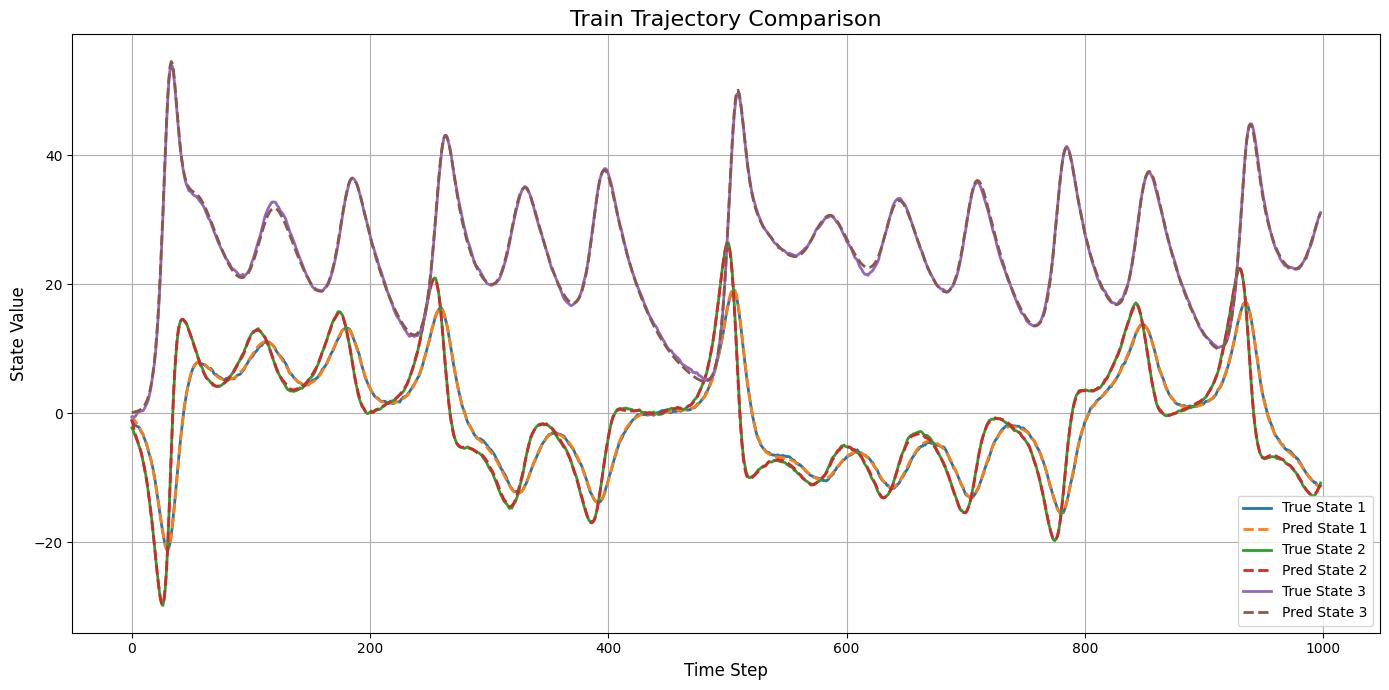

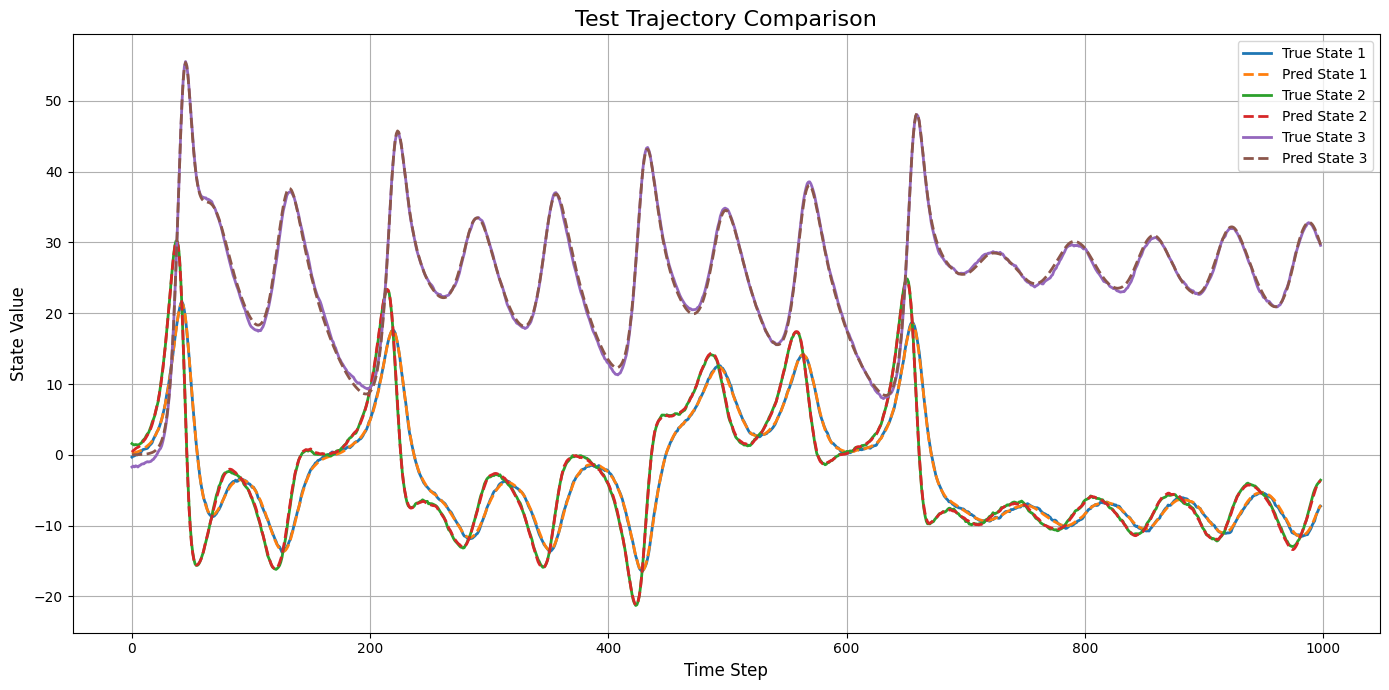

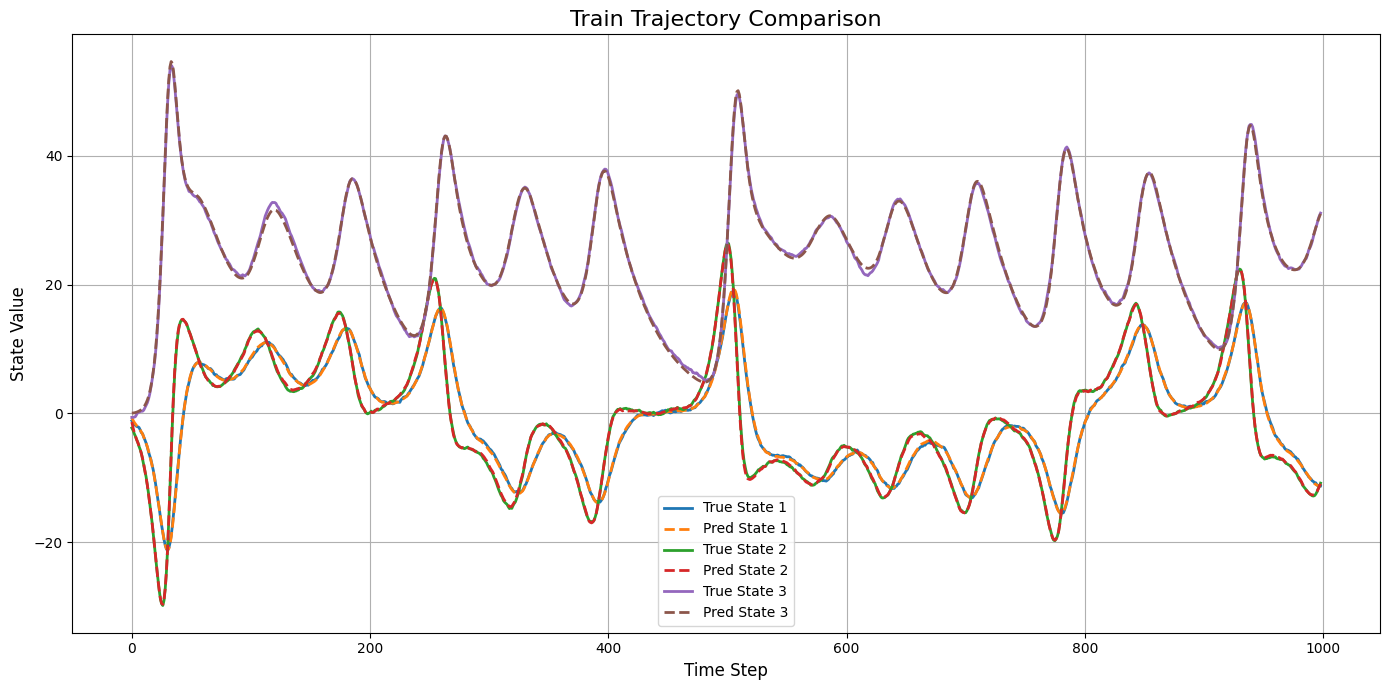

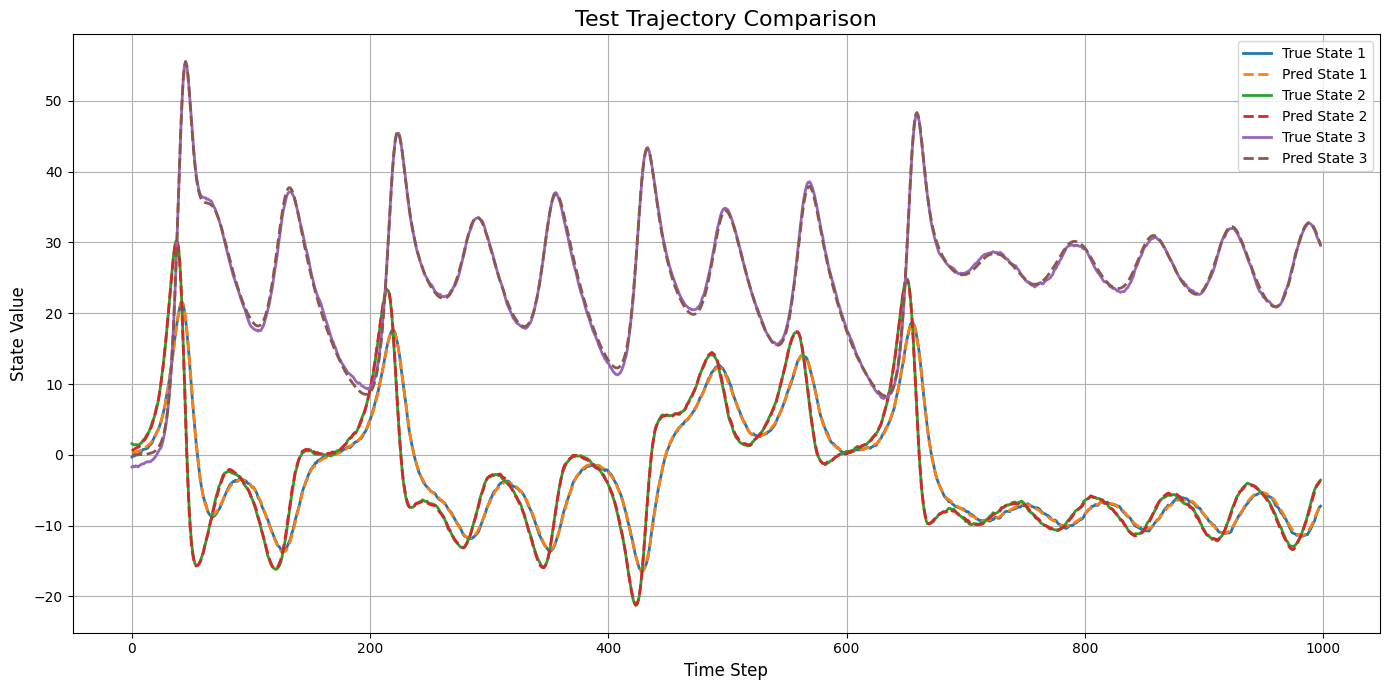

In [ ]:
plot_pred_vs_true_simple(model, next(iter(train_data)), title_prefix="Train")
plot_pred_vs_true_simple(model, next(iter(test_data)), title_prefix="Test")
plot_pred_vs_true_simple(model_optim, next(iter(train_data)), title_prefix="Train")
plot_pred_vs_true_simple(model_optim, next(iter(test_data)), title_prefix="Test")

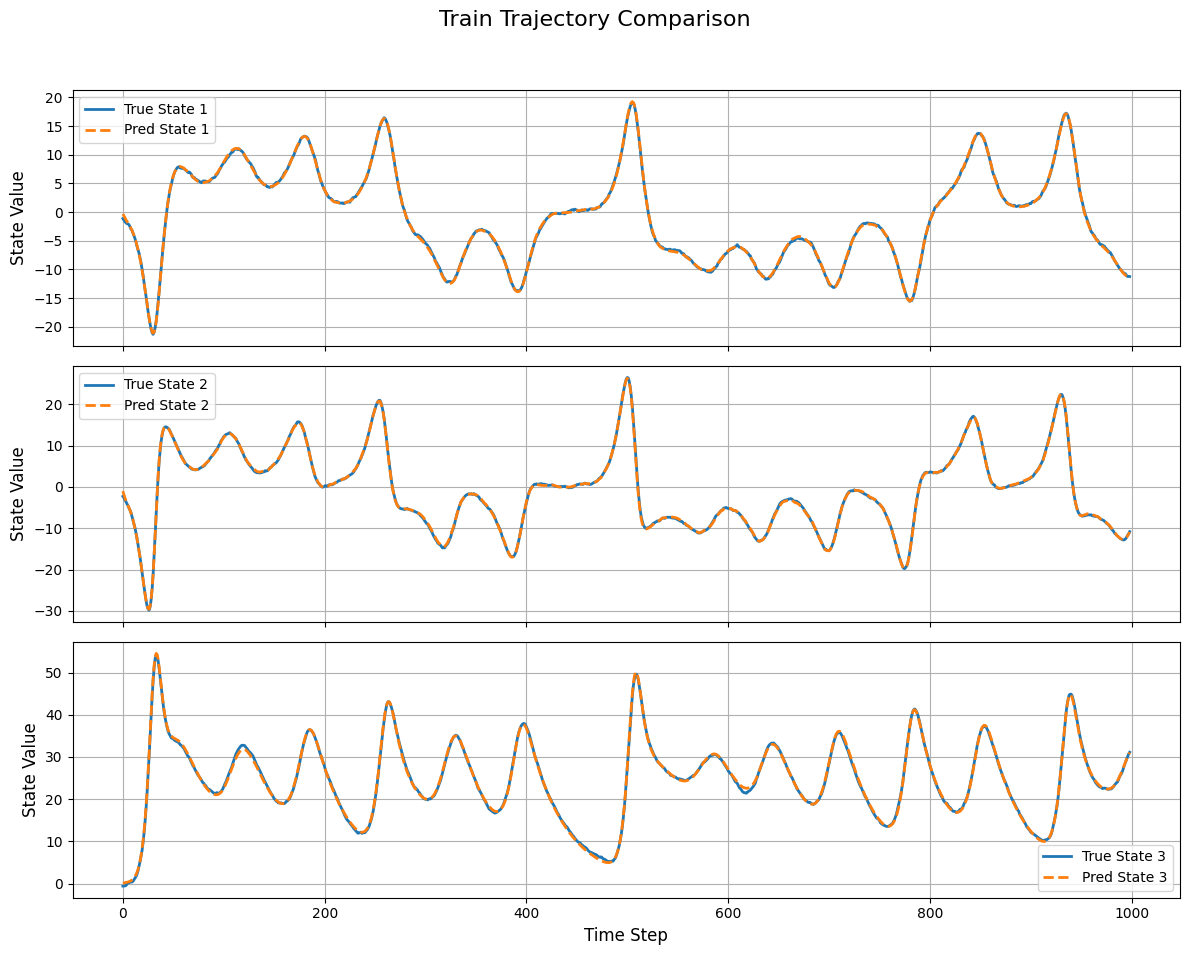

In [ ]:
def plot_pred_vs_true_subplots(model, batch, title_prefix="Train", figsize=(12, 10)):
    """
    Plots predictions vs. ground truth for each state dimension in a separate subplot.
    """
    model.eval()
    y_seq, x_true = batch
    
    x0 = torch.zeros_like(x_true[:, 0, :, :]) 
    T = y_seq.shape[1]
    model.InitSequence(x0, T)
    
    with torch.no_grad():
        x_pred, _ = model(y_seq[:, 1:]) 

    x_true = x_true[:, 1:, :, :]      

    idx_to_plot = 0
    pred_np = x_pred[idx_to_plot].cpu().numpy()  
    true_np = x_true[idx_to_plot].cpu().numpy()  

    time = np.arange(pred_np.shape[0])
    num_states = pred_np.shape[1]

  
    fig, axes = plt.subplots(nrows=num_states, ncols=1, figsize=figsize, sharex=True)
    fig.suptitle(f'{title_prefix} Trajectory Comparison', fontsize=16)

    for state_dim in range(num_states):
        ax = axes[state_dim]
        
    
        ax.plot(time, true_np[:, state_dim].squeeze(), 
                label=f'True State {state_dim+1}', linewidth=2)
        ax.plot(time, pred_np[:, state_dim].squeeze(), '--', 
                label=f'Pred State {state_dim+1}', linewidth=2)
        
        ax.set_ylabel('State Value', fontsize=12)
        ax.legend()
        ax.grid(True)

   
    axes[-1].set_xlabel('Time Step', fontsize=12)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

-
plot_pred_vs_true_subplots(model, next(iter(train_data)), title_prefix="Train")